### Data Analysis & Visualizations

This notebook covers the full analysis pipeline for our project on the internationalisation of Copenhagen's neighbourhoods (1995–2025). It contains all analytical decisions, visualizations, and the discussion of findings.

**Sections:**
1. Setup & Imports
2. Data Loading & Cleaning
3. Exploratory Data Analysis
4. Data Analysis & Machine Learning
5. Visualizations
6. Key Findings Summary
7. Discussion
8. Notes on Methodology

## 0. Setup & Imports

We import the core libraries used throughout the notebook. `pandas` and `numpy` handle data loading and manipulation; `matplotlib` and `seaborn` produce static charts, `plotly` and `folium` power the interactive charts and geographic heatmaps; and `scikit-learn` supplies the clustering (KMeans), dimensionality reduction (PCA), and regression tools. A consistent visual theme is applied globally so all static figures share the same look.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import folium
from folium.plugins import HeatMap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Consistent style for matplotlib/seaborn charts
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All imports OK')

All imports OK


---
## 1. Motivation

Copenhagen is frequently cited as one of Europe’s most livable cities, but broad city-level statistics can hide important local differences. Over the last 30 years, the city has grown substantially and become increasingly international, with roughly one quarter of residents now having an immigrant or descendant background.

This project investigates how that demographic transformation developed across Copenhagen’s districts between 1995 and 2025. Rather than treating the city as one uniform population, the analysis focuses on neighbourhood-level change: which districts changed most, which changed more slowly, and whether distinct spatial patterns emerged over time.

The goal of the project is to create an accessible, interactive data story that allows readers to explore Copenhagen’s demographic development visually. Through maps, timelines, clustering, and district comparisons, users can examine how internationalisation evolved across the city and how neighbourhood trajectories differ from one another.

The intended audience is non-technical readers, such as students, residents, or policymakers interested in understanding how Copenhagen has changed over time through data and visualisation.


---
## 2. Data Overview

**Sources**
Two datasets drive the analysis, both sourced from Copenhagen Municipality (Københavns Kommune) and Statistics Denmark:

- **District-level population by ancestry** (`cleaned_merged_output_final.csv`): annual counts from 1995 to 2025 across 10 main boroughs, broken down by ancestry group (Danish origin, western immigrants/descendants, non-western immigrants/descendants). Also includes average income columns from 2008 onward.
- **Country-of-origin** (`country-by-origin-cleaned.csv`): city-level counts of immigrants and descendants by country of birth, covering the same period.

**Key preprocessing decisions**
- **Borough filtering**: the raw file contains sub-quarter rows and a city-total aggregation row. We keep only the 10 named borough-level districts to avoid double-counting.
- **Ancestry grouping**: granular ancestry labels are grouped into four categories (western immigrants, western descendants, non-western immigrants, non-western descendants) for consistent aggregation across sections.
- **Numeric coercion**: year columns and income figures are cast to numeric, with non-parseable values set to `NaN` rather than dropped, so the district-year grid stays intact.

**Three patterns that stood out in early exploration**
- The international share accelerated noticeably after 2015, particularly in Bispebjerg and Brønshøj-Husum.
- The gap in international share *between* districts was narrow in 1995 and has widened substantially by 2025, districts are diverging, not converging.
- Average income for non-western origin residents (~250k DKK/yr) has remained roughly 200k DKK below the Danish-origin average (~450k DKK/yr) throughout the period, a persistent gap that provides economic context for the geographic patterns.


---
## 3. Load & Clean the Data

The raw file contains population counts broken down by **district** and **ancestry group** for each year from 1995 to 2025. We filter it down to Copenhagen's **10 main borough-level districts**, discarding sub-quarter rows and the city-total aggregation. Year columns are coerced to numeric to allow arithmetic operations later.

In [52]:
# District-level dataset 
df_raw = pd.read_csv('../data/cleaned_merged_output_final.csv', sep=';')

year_cols  = [c for c in df_raw.columns if c.isdigit()]
income_cols = [c for c in df_raw.columns if 'income' in c]

# Keep only the 10 main borough-level districts (drop sub-quartier rows,
# 'Local committee' rows, and the city-total row)
MAIN_DISTRICTS = [
    'Indre By', 'Østerbro', 'Nørrebro', 'Vesterbro/Kongens Enghave',
    'Valby', 'Vanløse', 'Brønshøj-Husum', 'Bispebjerg',
    'Amager Øst', 'Amager Vest'
]
df = df_raw[df_raw['district'].isin(MAIN_DISTRICTS)].copy()

# Convert year columns to numeric
for c in year_cols + income_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'Rows kept: {len(df)}  |  Districts: {df["district"].nunique()}  |  Ancestry groups: {df["ancestry"].nunique()}')
df.head()

Rows kept: 60  |  Districts: 10  |  Ancestry groups: 6


,age_group,sex,ancestry,district,1995,1996,1997,1998,1999,2000,...,avg_income_dkk_2015,avg_income_dkk_2016,avg_income_dkk_2017,avg_income_dkk_2018,avg_income_dkk_2019,avg_income_dkk_2020,avg_income_dkk_2021,avg_income_dkk_2022,avg_income_dkk_2023,avg_income_dkk_2024
1,Years in total,Sex total,Ancestry total,Indre By,41340.0,41544.0,42175.0,42483.0,43188.0,43457.0,...,218440,223635,229793,237224,245734,257297,272650,271940,287039,303697
2,Years in total,Sex total,Ancestry total,Østerbro,63207.0,64045.0,65276.0,65603.0,66087.0,66456.0,...,218440,223635,229793,237224,245734,257297,272650,271940,287039,303697
3,Years in total,Sex total,Ancestry total,Nørrebro,68508.0,69517.0,70631.0,71205.0,72156.0,72712.0,...,218440,223635,229793,237224,245734,257297,272650,271940,287039,303697
4,Years in total,Sex total,Ancestry total,Vesterbro/Kongens Enghave,47336.0,47408.0,48023.0,48944.0,49353.0,50103.0,...,218440,223635,229793,237224,245734,257297,272650,271940,287039,303697
5,Years in total,Sex total,Ancestry total,Valby,43634.0,45001.0,45277.0,45669.0,46002.0,46100.0,...,218440,223635,229793,237224,245734,257297,272650,271940,287039,303697


A second dataset records population by **country of origin** at the city level. We exclude Denmark itself (only foreign-origin individuals are relevant here) and retain only the `Immigrants` and `Descendant` ancestry categories to build a picture of where Copenhagen's international population actually comes from.

In [53]:
# Country-of-origin dataset
df_country = pd.read_csv('../data/country-by-origin-cleaned.csv')

# Drop Denmark itself (not 'international') and the generic 'Persons of Danish origin'
df_foreign = df_country[
    (df_country['ancestry'].isin(['Immigrants', 'Descendant'])) &
    (df_country['country'] != 'Denmark')
].copy()

print(f'Country dataset: {len(df_foreign)} rows  |  {df_foreign["country"].nunique()} countries  |  years {df_foreign["year"].min()}–{df_foreign["year"].max()}')
df_foreign.head()

Country dataset: 74164 rows  |  216 countries  |  years 1995–2026


,ancestry,age,country,year,population
0,Descendant,0-9 years,Afghanistan,1995,123
1,Descendant,0-9 years,Afghanistan,1996,163
2,Descendant,0-9 years,Afghanistan,1997,208
3,Descendant,0-9 years,Afghanistan,1998,259
4,Descendant,0-9 years,Afghanistan,1999,312


### 3.1 Derived helper tables

In [54]:
# Long-format population table (needed for visualizations)
year_cols_all = [str(y) for y in range(1995, 2026)]

# Only melt on columns that actually exist in district_df
id_cols = [c for c in ["ancestry", "district"] if c in df.columns]

population_long = df.melt(
    id_vars=id_cols,
    value_vars=[y for y in year_cols_all if y in df.columns],
    var_name="year",
    value_name="population"
)

population_long["year"] = population_long["year"].astype(int)
population_long["population"] = pd.to_numeric(population_long["population"], errors="coerce")

print(f'population_long shape: {population_long.shape}')
population_long.head()

population_long shape: (1860, 4)


,ancestry,district,year,population
0,Ancestry total,Indre By,1995,41340.0
1,Ancestry total,Østerbro,1995,63207.0
2,Ancestry total,Nørrebro,1995,68508.0
3,Ancestry total,Vesterbro/Kongens Enghave,1995,47336.0
4,Ancestry total,Valby,1995,43634.0


In [55]:
# District coordinates for map visualizations
district_coords = pd.DataFrame({
    "district": [
        "Indre By", "Østerbro", "Nørrebro", "Vesterbro/Kongens Enghave",
        "Valby", "Vanløse", "Brønshøj-Husum", "Bispebjerg",
        "Amager Øst", "Amager Vest"
    ],
    "lat": [
        55.6840, 55.7047, 55.6996, 55.6680,
        55.6624, 55.6872, 55.7078, 55.7182,
        55.6627, 55.6456
    ],
    "lon": [
        12.5900, 12.5770, 12.5481, 12.5450,
        12.5167, 12.4915, 12.4982, 12.5337,
        12.6208, 12.5836
    ]
})

Rather than recomputing the same aggregations repeatedly, we pre-build a set of **helper DataFrames** that are reused across every analysis:

- `df_total` : total population per district per year (the denominator for shares)
- `nonwestern` / `western` : counts of non-western and western immigrants + descendants
- `all_immigrants` : all international residents combined
- `share` : percentage of the district population that is international (the main metric)
- `nw_share` : non-western share specifically (used for clustering and forecasting)

Computing these once avoids repetition and ensures consistency across figures.

In [56]:
# Total population per district per year 
df_total = df[df['ancestry'] == 'Ancestry total'][['district'] + year_cols].set_index('district')

# Non-western immigrants + descendants per district per year
nonwestern = df[
    df['ancestry'].isin(['Immigrants of non-western origin', 'Descendants of non-western origin'])
].groupby('district')[year_cols].sum()

# Western immigrants + descendants per district per year
western = df[
    df['ancestry'].isin(['Immigrants of western origin', 'Descendats of western origin'])
].groupby('district')[year_cols].sum()

# All immigrants (western + non-western) per district per year
all_immigrants = df[
    df['ancestry'].isin([
        'Immigrants of non-western origin', 'Descendants of non-western origin',
        'Immigrants of western origin',     'Descendats of western origin'
    ])
].groupby('district')[year_cols].sum()

# Share of internationals per district per year (%)
share = (all_immigrants / df_total * 100).dropna()

# Non-western share specifically
nw_share = (nonwestern / df_total * 100).dropna()

print('Helper tables built.')
share.round(1)

Helper tables built.


,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
district,,,,,,,,,,,,,,,,,,,,,
Amager Vest,12.4,13.1,13.9,14.6,15.5,16.4,17.3,17.8,18.4,18.8,...,23.9,24.5,25.4,26.2,27.2,28.0,29.4,31.5,32.9,33.9
Amager Øst,12.0,12.6,13.5,14.1,14.6,14.8,15.1,15.3,15.6,15.8,...,20.1,20.3,20.7,21.6,21.7,21.9,22.2,23.4,24.3,24.8
Bispebjerg,13.3,15.0,16.4,17.5,18.5,19.8,20.6,21.5,22.0,22.4,...,33.6,34.0,34.0,34.2,34.0,33.8,34.0,34.5,34.9,34.7
Brønshøj-Husum,11.4,12.3,14.2,15.3,16.6,17.5,18.6,19.6,20.5,21.0,...,35.6,36.0,36.3,36.8,36.7,36.6,36.7,37.1,37.8,38.4
Indre By,10.2,10.3,10.5,10.8,11.6,11.6,11.8,12.0,12.2,12.4,...,18.3,19.3,20.5,20.9,20.7,20.8,21.4,22.3,22.7,22.9
Nørrebro,21.0,22.3,23.4,24.4,25.2,25.5,25.9,26.5,26.5,26.7,...,26.4,26.4,26.4,26.7,26.7,26.5,26.4,26.7,27.1,27.2
Valby,10.5,11.9,12.7,13.5,14.3,15.0,15.5,16.1,16.8,17.2,...,23.2,24.0,24.8,25.3,26.0,26.0,26.9,29.3,29.4,29.6
Vanløse,6.4,6.9,7.4,7.7,8.2,8.8,9.2,9.5,9.8,10.3,...,16.4,16.9,17.6,18.3,18.5,18.4,18.8,19.7,20.0,20.2
Vesterbro/Kongens Enghave,18.5,18.8,19.3,19.7,19.8,20.1,20.3,20.3,20.4,20.1,...,22.7,23.1,23.6,24.0,24.8,25.2,25.8,27.0,28.1,28.7


---
## 4. Exploratory Data Analysis

### 4.1 Overall internationalisation trend in Copenhagen

Before drilling into districts, it helps to see the **city-wide picture first**. This chart sums all 10 main districts to show the overall share of international residents from 1995 to 2025. A reference line marks 2015 the year of the European refugee crisis, which caused a visible spike in several indicators. The shaded area makes the upward trend easy to grasp at a glance.

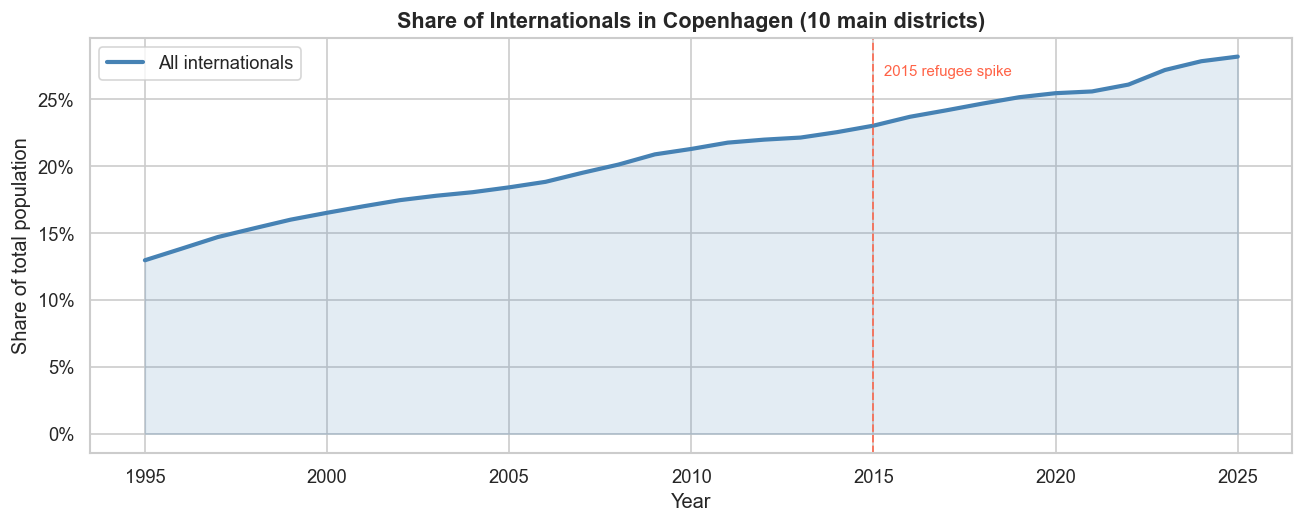

Share in 1995: 13.0%  →  2025: 28.2%


In [57]:
# City-wide totals from the district-level data (sum of 10 main districts)
city_total  = df_total.loc[MAIN_DISTRICTS].sum()
city_intl   = all_immigrants.loc[[d for d in MAIN_DISTRICTS if d in all_immigrants.index]].sum()
city_nw     = nonwestern.loc[[d for d in MAIN_DISTRICTS if d in nonwestern.index]].sum()
city_share  = city_intl / city_total * 100

years_int = [int(y) for y in year_cols]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(years_int, city_share.values, alpha=0.15, color='steelblue')
ax.plot(years_int, city_share.values, color='steelblue', linewidth=2.5, label='All internationals')
ax.axvline(2015, color='tomato', linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(2015.3, city_share.max() * 0.95, '2015 refugee spike', color='tomato', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Share of Internationals in Copenhagen (10 main districts)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Share of total population')
ax.legend()
plt.tight_layout()
plt.savefig("images/fig_01_city_trend.png", bbox_inches='tight')
plt.show()
print(f'Share in 1995: {city_share["1995"]:.1f}%  →  2025: {city_share["2025"]:.1f}%')

### 4.2 District-level breakdown: who grew the most?

Not all districts internationalised at the same pace. This line chart plots each district's international share over the full 30-year period, making it easy to spot which neighbourhoods experienced the steepest growth and which remained relatively stable. The following bar chart makes the ranking explicit by showing the **net percentage-point change** from 1995 to 2025 for each district.

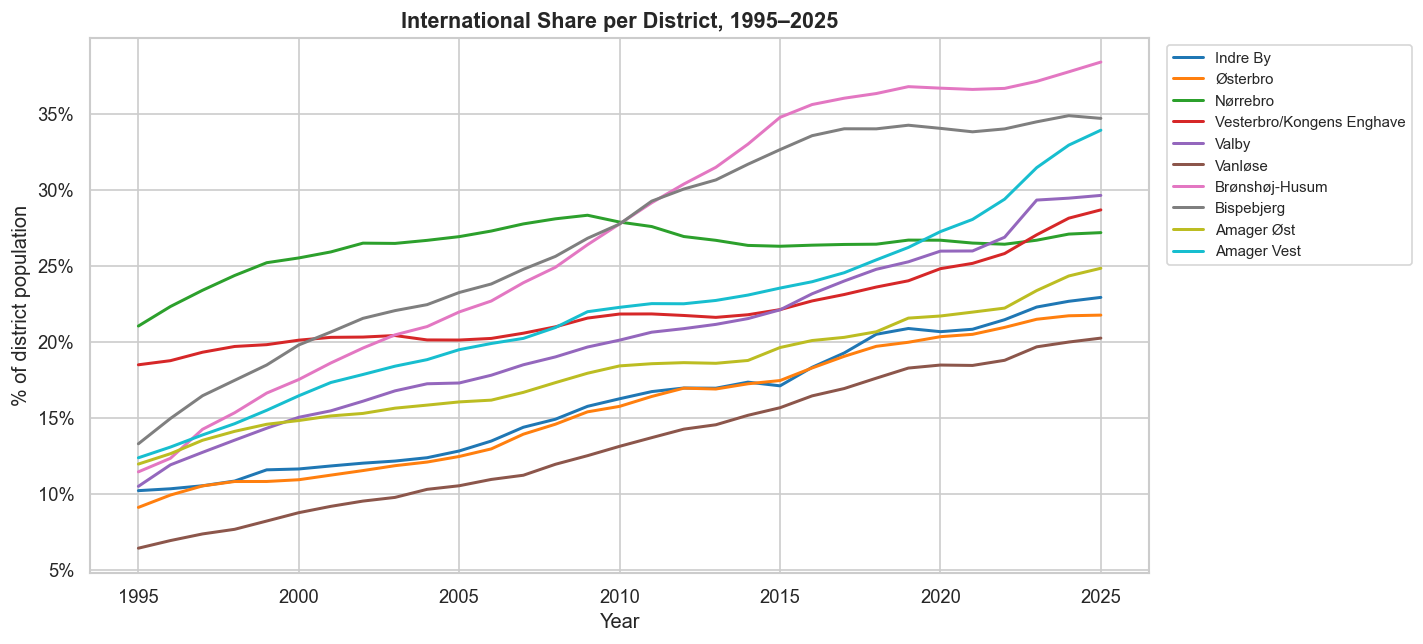

In [58]:
fig, ax = plt.subplots(figsize=(12, 5.5))

colors = plt.cm.tab10(np.linspace(0, 1, len(MAIN_DISTRICTS)))
for i, d in enumerate(MAIN_DISTRICTS):
    if d in share.index:
        ax.plot(years_int, share.loc[d].values, label=d, color=colors[i], linewidth=1.8)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('International Share per District, 1995–2025', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('% of district population')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig("images/fig_02_district_trends.png", bbox_inches='tight')
plt.show()

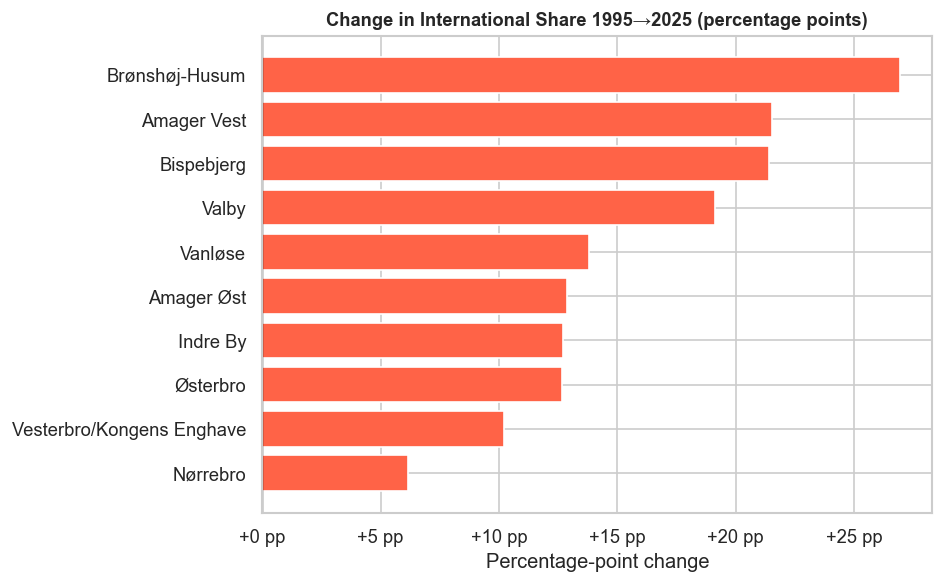

In [59]:
# Change from 1995 → 2025 (percentage point)
delta = share['2025'] - share['1995']
delta_sorted = delta.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['tomato' if v > 0 else 'steelblue' for v in delta_sorted.values]
ax.barh(delta_sorted.index, delta_sorted.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('+%.0f pp' if True else '%.0f pp'))
ax.set_title('Change in International Share 1995→2025 (percentage points)', fontsize=11, fontweight='bold')
ax.set_xlabel('Percentage-point change')
plt.tight_layout()
plt.savefig("images/fig_03_delta_bar.png", bbox_inches='tight')
plt.show()

### 4.3 Heatmap - share over time by district

A heatmap compresses the full time series into a single readable table by sampling every 5 years. Each cell shows the international share (%) for one district in one year, with colour intensity encoding magnitude. This makes it straightforward to compare districts horizontally (who is highest?) and track trajectories vertically (how fast did each grow?).

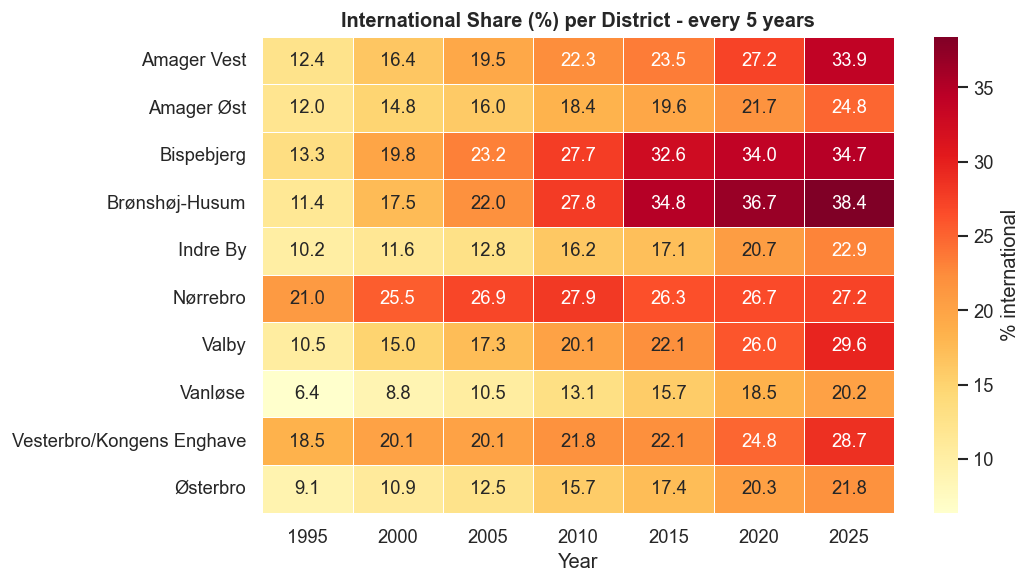

In [60]:
# Resample to every 5 years for readability
snap_years = ['1995','2000','2005','2010','2015','2020','2025']
heatmap_data = share[[y for y in snap_years if y in share.columns]]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    heatmap_data.round(1),
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.4, ax=ax, cbar_kws={'label': '% international'}
)
ax.set_title('International Share (%) per District - every 5 years', fontsize=12, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig("images/fig_04_heatmap.png", bbox_inches='tight')
plt.show()

### 4.4 Income gap by ancestry group

Demographic change rarely happens in isolation from economic inequality. This section asks: **do different ancestry groups earn different incomes, and how has that gap evolved?** We use city-wide average income data (available from 2008) broken down into five ancestry categories. Persistent or widening gaps would suggest structural barriers in the labour market beyond compositional differences.

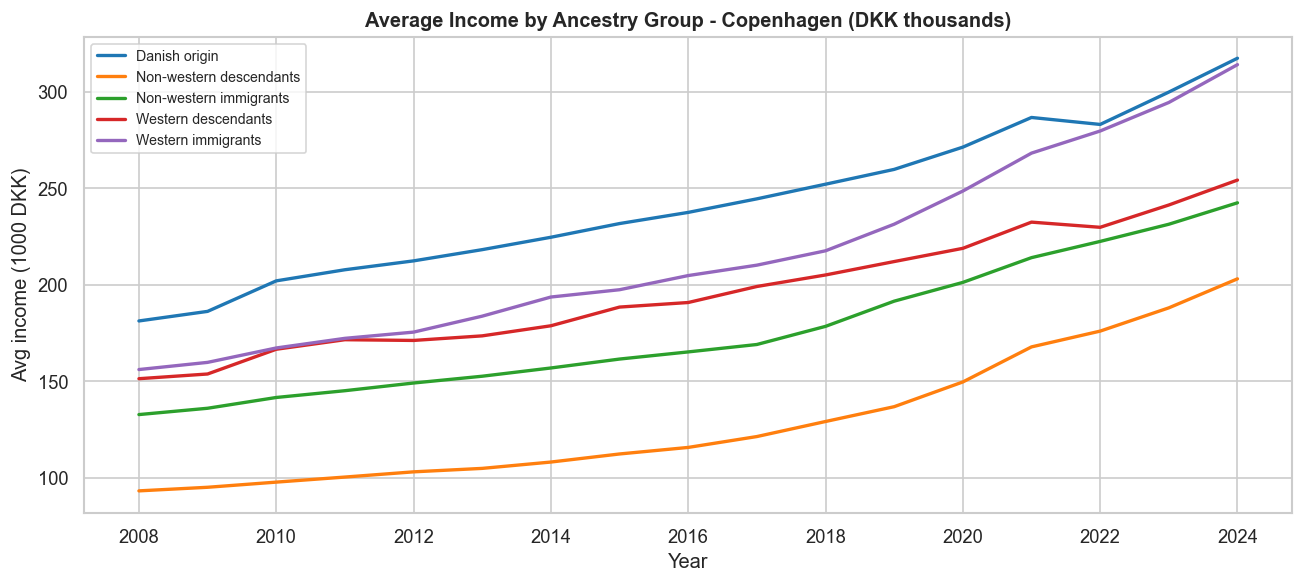

In [61]:
# Use Copenhagen total rows for a clean city-wide income picture
# (income is aggregated at district level, we use Nørrebro as a representative and the whole-city row is available in the full dataset)

income_rows = df_raw[
    (df_raw['district'] == 'Copenhagen total') &
    (df_raw['ancestry'] != 'Ancestry total')
][['ancestry'] + income_cols].copy()

for c in income_cols:
    income_rows[c] = pd.to_numeric(income_rows[c], errors='coerce')

# Melt to long format
income_long = income_rows.melt(id_vars='ancestry', var_name='year_str', value_name='avg_income')
income_long['year'] = income_long['year_str'].str.extract(r'(\d+)').astype(int)

# Short labels
label_map = {
    'Persons of danish origin':          'Danish origin',
    'Immigrants of western origin':       'Western immigrants',
    'Descendats of western origin':       'Western descendants',
    'Immigrants of non-western origin':   'Non-western immigrants',
    'Descendants of non-western origin':  'Non-western descendants',
}
income_long['group'] = income_long['ancestry'].map(label_map)

fig, ax = plt.subplots(figsize=(11, 5))
for grp, grp_df in income_long.groupby('group'):
    grp_df = grp_df.dropna(subset=['avg_income']).sort_values('year')
    ax.plot(grp_df['year'], grp_df['avg_income'] / 1000, label=grp, linewidth=2)

ax.set_title('Average Income by Ancestry Group - Copenhagen (DKK thousands)', fontsize=12, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Avg income (1000 DKK)')
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig("images/fig_05_income_gap.png", bbox_inches='tight')
plt.show()

---
## 5. Data Analysis

### 5.1 Clustering districts by their internationalisation profile

With 10 districts and 30 years of data, patterns become clearer when we group districts that behaved similarly. We use **KMeans clustering** on non-western share at 7 time snapshots (1995–2025) to find natural groupings. Features are standardised before fitting so that no single year dominates the distance metric. The elbow plot below guides the choice of *k* by showing where adding another cluster yields diminishing returns in reducing inertia.

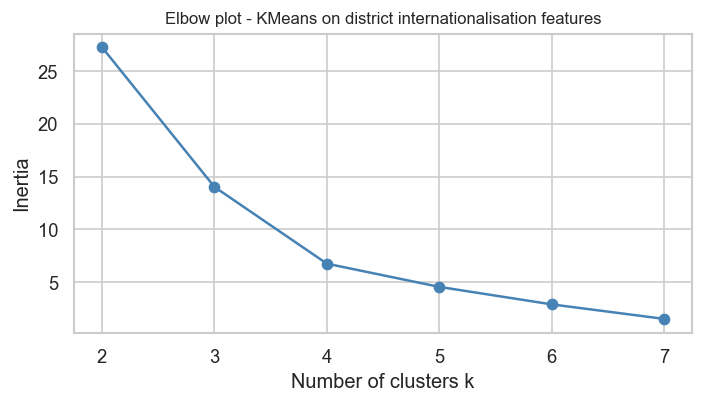

In [62]:
# Feature matrix: non-western share at several time snapshots
# (non-western is the more policy-relevant and historically stable signal)

feature_years = ['1995', '2000', '2005', '2010', '2015', '2020', '2025']
X = nw_share[[y for y in feature_years if y in nw_share.columns]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to pick k
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(list(K_range), inertias, 'o-', color='steelblue')
ax.set_xlabel('Number of clusters k'); ax.set_ylabel('Inertia')
ax.set_title('Elbow plot - KMeans on district internationalisation features', fontsize=10)
plt.tight_layout()
plt.savefig("images/fig_06_elbow.png", bbox_inches='tight')
plt.show()

The elbow plot suggests **k = 3** as the sweet spot, a meaningful split without over-segmenting the small set of districts. We refit with k=3 and name the clusters by their average non-western share in 2025: *Low*, *Medium*, and *High internationalisation*.

In [63]:
# k=3 gives a clean, interpretable elbow
K_BEST = 3
km = KMeans(n_clusters=K_BEST, random_state=42, n_init=20)
labels = km.fit_predict(X_scaled)

cluster_df = X.copy()
cluster_df['cluster'] = labels

# Name clusters by mean non-western share in 2025
cluster_means_2025 = cluster_df.groupby('cluster')['2025'].mean().sort_values()
rank_map = {old: new for new, old in enumerate(cluster_means_2025.index)}
cluster_df['cluster_named'] = cluster_df['cluster'].map(rank_map).map({
    0: 'Low internationalisation',
    1: 'Medium internationalisation',
    2: 'High internationalisation',
})

print(cluster_df[['cluster_named'] + feature_years].sort_values('cluster_named').round(1).to_string())

                                         cluster_named  1995  2000  2005  2010  2015  2020  2025
district                                                                                        
Bispebjerg                   High internationalisation   9.7  15.9  19.2  21.7  24.4  23.8  23.7
Brønshøj-Husum               High internationalisation   8.3  14.4  18.9  23.2  27.9  29.7  31.7
Nørrebro                     High internationalisation  16.4  20.8  21.7  20.9  18.4  17.3  16.8
Indre By                      Low internationalisation   3.0   3.4   4.0   5.1   5.2   6.4   7.6
Vanløse                       Low internationalisation   3.5   5.4   7.2   8.5  10.2  11.6  12.6
Østerbro                      Low internationalisation   4.2   5.4   6.5   8.2   8.7   9.9  10.5
Amager Vest                Medium internationalisation   8.3  12.0  14.4  14.8  14.8  16.0  19.2
Amager Øst                 Medium internationalisation   7.9  10.0  10.8  11.7  11.3  11.6  13.0
Valby                      Med

Clustering was performed in the original 7-dimensional feature space, but we can visualise the result in 2D by projecting onto the first two **principal components** (PCA). If the clusters are well-separated in this projection, it confirms that the grouping captures real structure in the data rather than artefacts of the algorithm.

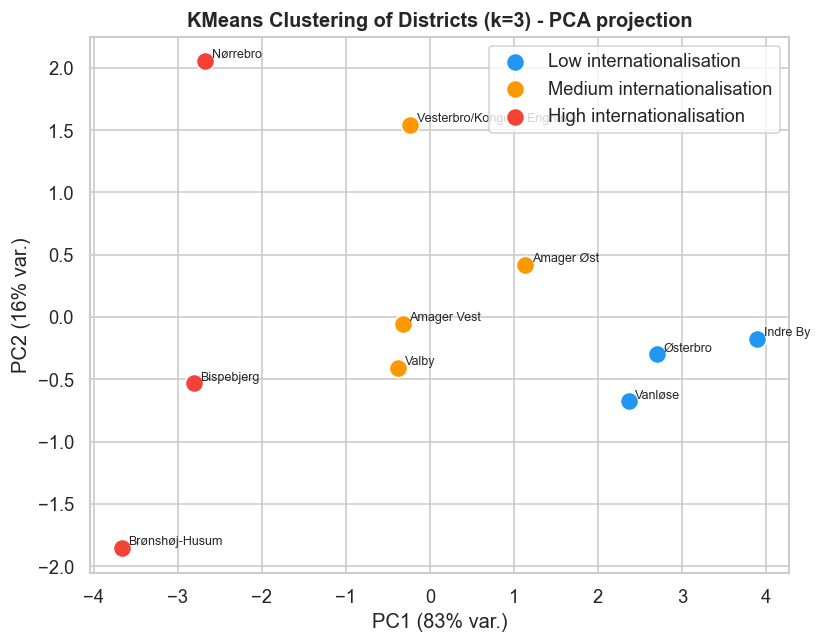

In [64]:
# Visualise clusters in PCA space
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7, 5.5))
palette = {'Low internationalisation': '#2196F3',
           'Medium internationalisation': '#FF9800',
           'High internationalisation': '#F44336'}

for cluster_name, color in palette.items():
    mask = cluster_df['cluster_named'] == cluster_name
    ax.scatter(coords[mask, 0], coords[mask, 1],
               label=cluster_name, color=color, s=120, edgecolors='white', linewidth=1)
    for idx, district in enumerate(X.index):
        if mask[district]:
            ax.annotate(district, (coords[list(X.index).index(district), 0],
                                   coords[list(X.index).index(district), 1]),
                        fontsize=7.5, ha='left', xytext=(4, 2), textcoords='offset points')

ax.set_xlabel(f'PC1 ({explained[0]:.0f}% var.)')
ax.set_ylabel(f'PC2 ({explained[1]:.0f}% var.)')
ax.set_title('KMeans Clustering of Districts (k=3) - PCA projection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("images/fig_07_pca_clusters.png", bbox_inches='tight')
plt.show()

Labels alone don't tell the full story. Here we plot each cluster's **mean non-western share trajectory** over time, with individual district lines shown in the background for context. This reveals not just where each cluster *is* in 2025, but *how it got there* steady growth, rapid acceleration, or relative stability.

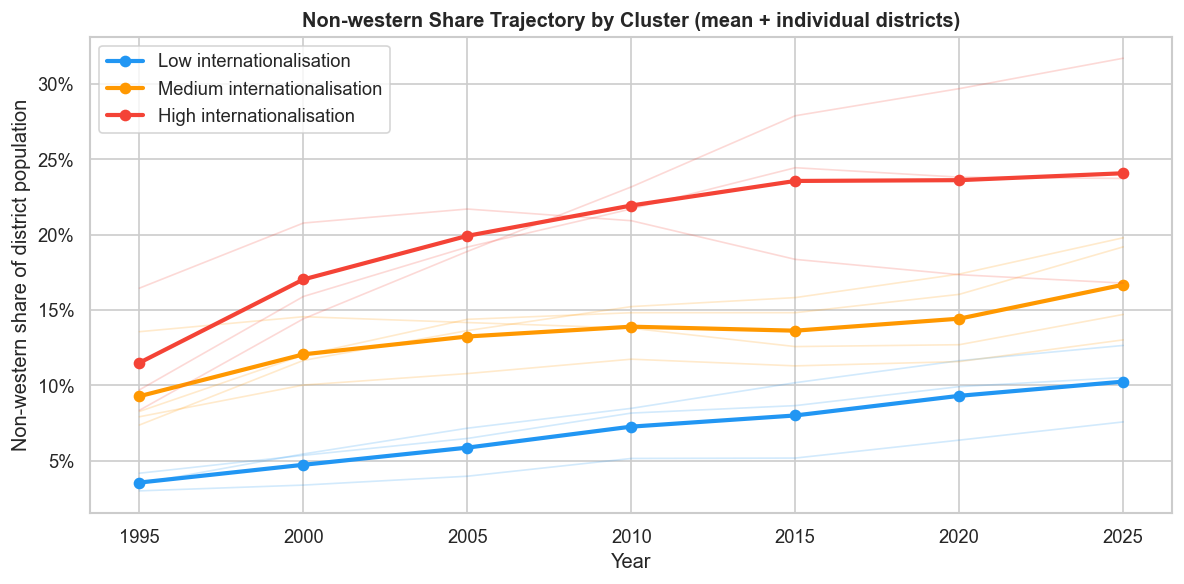

In [65]:
# Cluster trajectories over time
cluster_df_long = cluster_df.copy()
cluster_df_long = cluster_df_long.reset_index().melt(
    id_vars=['district', 'cluster_named'],
    value_vars=feature_years,
    var_name='year', value_name='nw_share'
)
cluster_df_long['year'] = cluster_df_long['year'].astype(int)
cluster_means = cluster_df_long.groupby(['cluster_named', 'year'])['nw_share'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for cname, color in palette.items():
    sub = cluster_means[cluster_means['cluster_named'] == cname]
    ax.plot(sub['year'], sub['nw_share'], 'o-', label=cname, color=color, linewidth=2.5, markersize=6)
    # Individual district lines (light)
    for d in cluster_df[cluster_df['cluster_named'] == cname].index:
        row = nw_share.loc[d, feature_years].values.astype(float)
        ax.plot([int(y) for y in feature_years], row, color=color, alpha=0.2, linewidth=1)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Non-western Share Trajectory by Cluster (mean + individual districts)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Non-western share of district population')
ax.legend()
plt.tight_layout()
plt.savefig("images/fig_08_cluster_trajectories.png", bbox_inches='tight')
plt.show()

### 5.2 Income gap by cluster

Now that districts are grouped, we can ask whether **cluster membership correlates with average income levels**. Districts with higher international shares may have lower average incomes due to the income gap documented in Section 2.4, or the relationship may be more nuanced. Plotting income trajectories by cluster surfaces that link clearly.

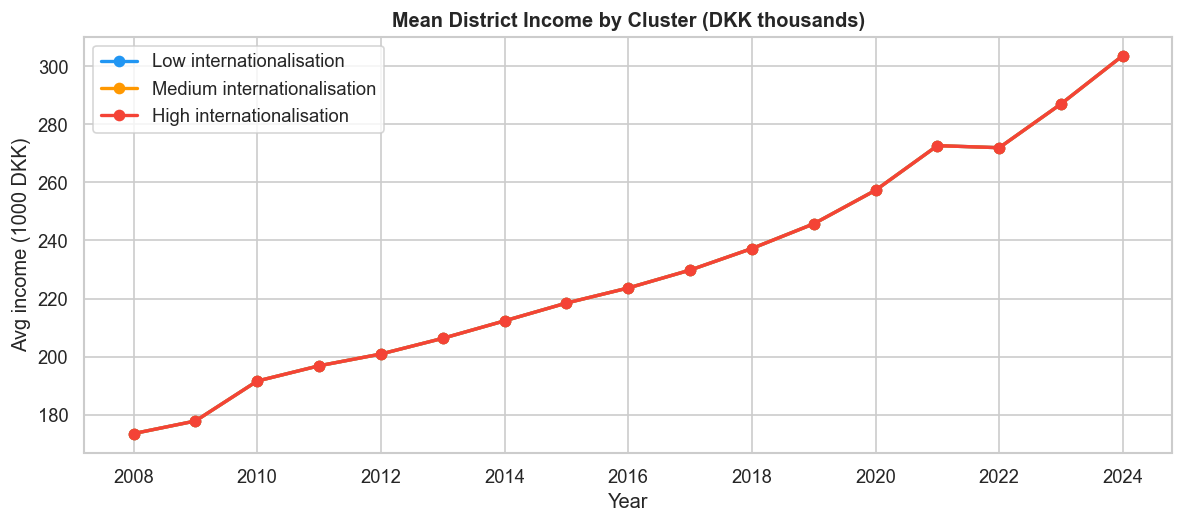

In [66]:
# Merge cluster labels into the income data (district-level)
# Use income for 'Ancestry total' at district level

income_district = df[
    (df['ancestry'] == 'Ancestry total') &
    (df['district'].isin(MAIN_DISTRICTS))
][['district'] + income_cols].copy()

for c in income_cols:
    income_district[c] = pd.to_numeric(income_district[c], errors='coerce')

income_district = income_district.set_index('district')
income_district['cluster'] = cluster_df['cluster_named']

income_long2 = income_district.reset_index().melt(
    id_vars=['district', 'cluster'], value_vars=income_cols,
    var_name='year_str', value_name='avg_income'
)
income_long2['year'] = income_long2['year_str'].str.extract(r'(\d+)').astype(int)
income_long2 = income_long2.dropna(subset=['avg_income', 'cluster'])

cluster_income = income_long2.groupby(['cluster', 'year'])['avg_income'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
for cname, color in palette.items():
    sub = cluster_income[cluster_income['cluster'] == cname]
    ax.plot(sub['year'], sub['avg_income'] / 1000, 'o-', label=cname, color=color, linewidth=2)

ax.set_title('Mean District Income by Cluster (DKK thousands)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Avg income (1000 DKK)')
ax.legend()
plt.tight_layout()
plt.savefig("images/fig_09_income_by_cluster.png", bbox_inches='tight')
plt.show()

---

### 5.3 Nationality composition - Copenhagen city level

The district-level data tells us *how many* internationals live in each neighbourhood, but not *where they come from*. The country-of-origin dataset fills this gap at the city level. We first identify the **top-10 origin countries** by cumulative population across all years, then trace their individual trajectories.

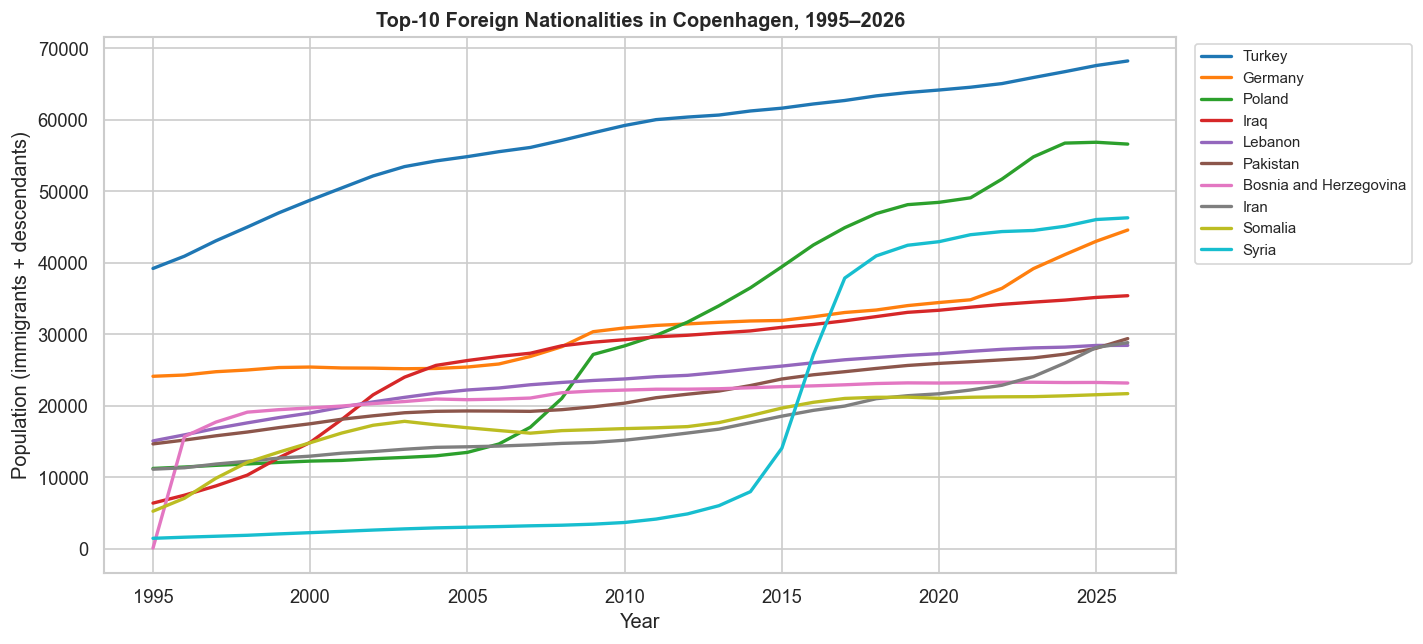

In [67]:
# Top-10 foreign countries by total population across all years
top10_countries = (
    df_foreign.groupby('country')['population'].sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

# Time-series for top-10
top10_ts = (
    df_foreign[df_foreign['country'].isin(top10_countries)]
    .groupby(['country', 'year'])['population'].sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5.5))
for country in top10_countries:
    sub = top10_ts[top10_ts['country'] == country]
    ax.plot(sub['year'], sub['population'], label=country, linewidth=2)

ax.set_title('Top-10 Foreign Nationalities in Copenhagen, 1995–2026', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Population (immigrants + descendants)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig("images/fig_10_top10_countries.png", bbox_inches='tight')
plt.show()

The time series shows trends, but a **snapshot pie chart for 2024** gives an immediate sense of the current composition: which nationalities make up the largest shares today, and how dominant are the top groups relative to the long tail of smaller communities?

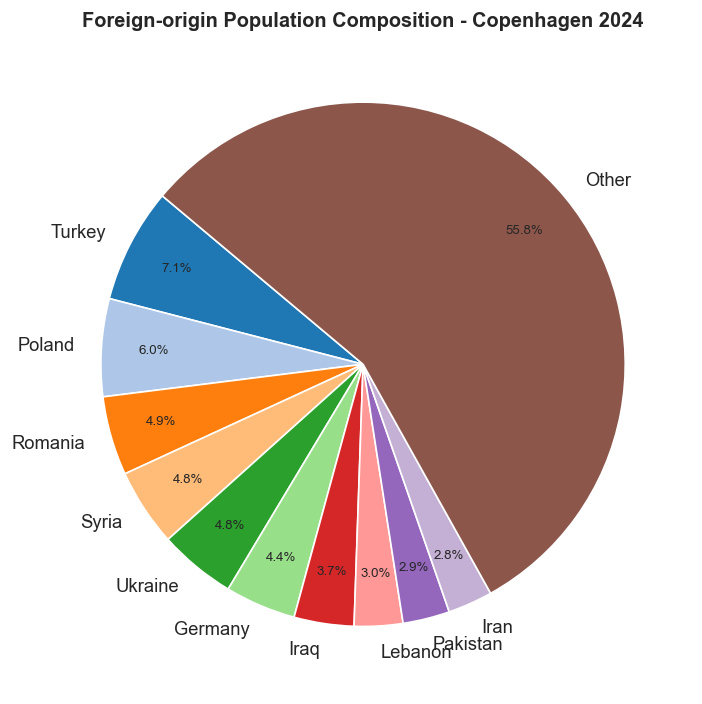

In [68]:
# Snapshot pie chart for 2024
snap_year = 2024
pie_data = (
    df_foreign[df_foreign['year'] == snap_year]
    .groupby('country')['population'].sum()
    .sort_values(ascending=False)
)

top_n = 10
top = pie_data.head(top_n)
other = pie_data.iloc[top_n:].sum()
plot_data = pd.concat([top, pd.Series({'Other': other})])

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    plot_data.values, labels=plot_data.index,
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.8,
    colors=sns.color_palette('tab20', len(plot_data))
)
for t in autotexts:
    t.set_fontsize(8)
ax.set_title(f'Foreign-origin Population Composition - Copenhagen {snap_year}', fontweight='bold')
plt.tight_layout()
plt.savefig("images/fig_11_pie_composition.png", bbox_inches='tight')
plt.show()

The stacked area chart combines both dimensions, time *and* composition, into a single view. It shows how the total foreign-origin population has grown while also revealing shifts in its national makeup: which groups have expanded, which have stabilised, and how much of the growth is accounted for by the catch-all *Other* category.

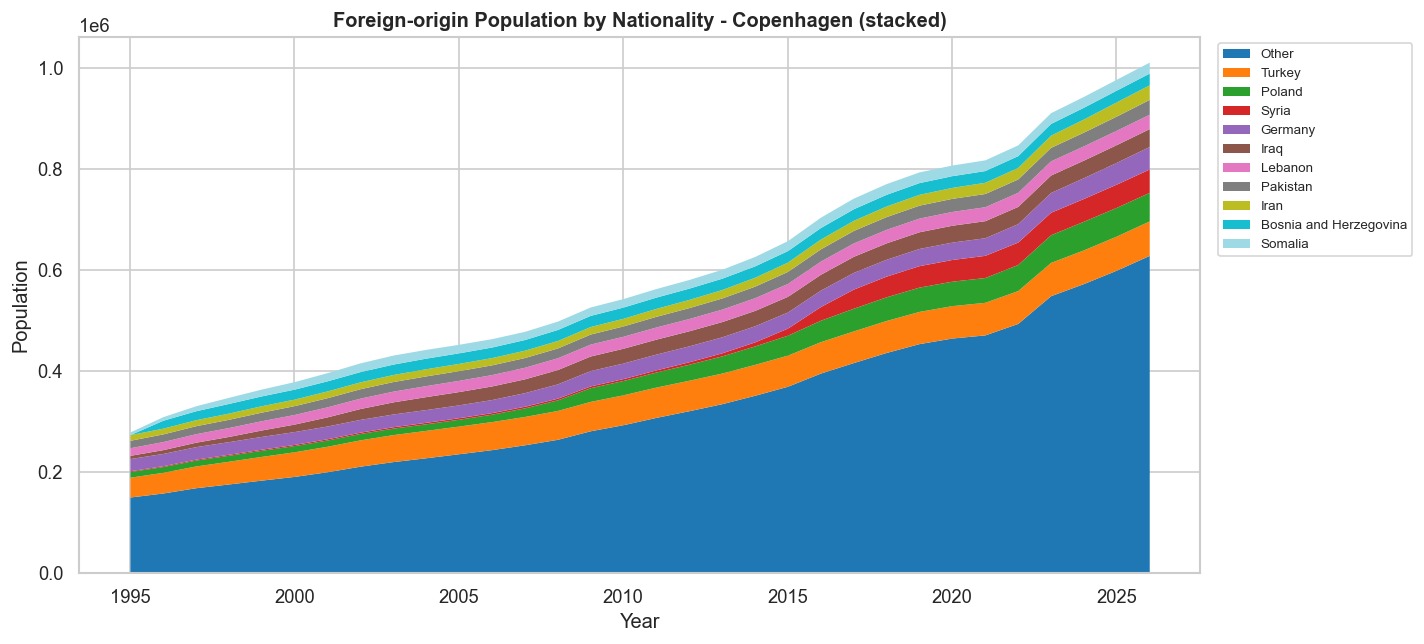

In [69]:
# Stacked area chart - top-10 + 'other', 1995–2026
stack_df = (
    df_foreign.copy()
)
stack_df['country_grouped'] = stack_df['country'].where(
    stack_df['country'].isin(top10_countries), 'Other'
)
pivot = (
    stack_df.groupby(['year', 'country_grouped'])['population'].sum()
    .unstack('country_grouped').fillna(0)
)
# Sort columns by 2024 size
col_order = pivot.loc[2024].sort_values(ascending=False).index.tolist()
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(12, 5.5))
pivot.plot.area(ax=ax, colormap='tab20', linewidth=0)
ax.set_title('Foreign-origin Population by Nationality - Copenhagen (stacked)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Population')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("images/fig_12_stacked_area.png", bbox_inches='tight')
plt.show()

---

### 5.4 Immigrants vs Descendants

A rising share of people counted as 'international' were actually **born in Denmark**. They are descendants of immigrants, not immigrants themselves. This generational shift has significant implications for integration, identity, and policy. This chart tracks the absolute numbers of first-generation immigrants versus second-generation descendants over time, making the crossover point (if any) visible.

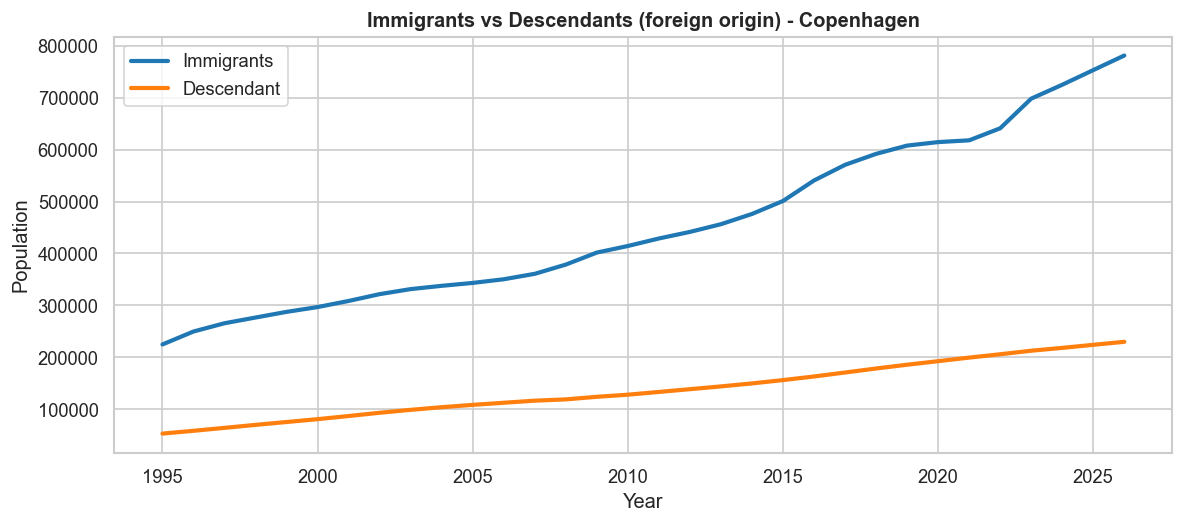

In [70]:
gen_ts = (
    df_foreign[df_foreign['country'] != 'Denmark']
    .groupby(['ancestry', 'year'])['population'].sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4.5))
for anc in ['Immigrants', 'Descendant']:
    sub = gen_ts[gen_ts['ancestry'] == anc]
    ax.plot(sub['year'], sub['population'], label=anc, linewidth=2.5)

ax.set_title('Immigrants vs Descendants (foreign origin) - Copenhagen', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Population')
ax.legend()
plt.tight_layout()
plt.savefig("images/fig_13_gen_shift.png", bbox_inches='tight')
plt.show()

---
## 6. Machine Learning: Forecasting internationalisation to 2035

We fit a simple **linear regression** on the non-western share time-series per district.  
This gives a *trend-based* forecast, which is useful for illustration but note that demographic trends often saturate, so extrapolation beyond ~10 years should be interpreted with caution.

We fit an ordinary least squares regression on the non-western share time series for each district (31 annual observations, 1995–2025). The slope of the regression line gives an estimate of the **annual percentage-point change** in non-western share. The table below reports R², slope, observed 2025 share, and projected 2035 share for every district high R² values (> 0.85 for most) confirm that the linear trend is a reasonable fit over the historical window.

In [71]:
# Prepare: use all 31 annual data points per district
years_full = np.array([int(y) for y in year_cols])
forecast_years = np.arange(2026, 2036)
all_years = np.concatenate([years_full, forecast_years])

results = {}
for district in MAIN_DISTRICTS:
    if district not in nw_share.index:
        continue
    y_vals = nw_share.loc[district, [str(yr) for yr in years_full]].values.astype(float)
    mask = ~np.isnan(y_vals)
    X_fit = years_full[mask].reshape(-1, 1)
    y_fit = y_vals[mask]
    if len(y_fit) < 5:
        continue
    model = LinearRegression()
    model.fit(X_fit, y_fit)
    y_pred_hist = model.predict(years_full[mask].reshape(-1, 1))
    y_pred_future = model.predict(forecast_years.reshape(-1, 1))
    # Clip at 0 (share can't be negative)
    y_pred_future = np.clip(y_pred_future, 0, 100)
    r2 = r2_score(y_fit, y_pred_hist)
    results[district] = {
        'model': model, 'r2': r2,
        'hist_years': years_full[mask], 'hist_vals': y_fit,
        'forecast_years': forecast_years, 'forecast_vals': y_pred_future,
        'slope': model.coef_[0]
    }

print('District          | R²    | Slope (pp/yr) | 2025 actual | 2035 forecast')
print('-'*75)
for d, r in sorted(results.items()):
    actual_2025 = nw_share.loc[d, '2025'] if '2025' in nw_share.columns else np.nan
    forecast_2035 = r['forecast_vals'][-1]
    print(f"{d:<35} | {r['r2']:.3f} | {r['slope']:+.3f}          | {actual_2025:>6.1f}%      | {forecast_2035:>6.1f}%")

District          | R²    | Slope (pp/yr) | 2025 actual | 2035 forecast
---------------------------------------------------------------------------
Amager Vest                         | 0.845 | +0.259          |   19.2%      |   20.7%
Amager Øst                          | 0.771 | +0.107          |   13.0%      |   13.6%
Bispebjerg                          | 0.844 | +0.442          |   23.7%      |   31.3%
Brønshøj-Husum                      | 0.972 | +0.773          |   31.7%      |   41.6%
Indre By                            | 0.970 | +0.155          |    7.6%      |    8.8%
Nørrebro                            | 0.305 | -0.119          |   16.8%      |   16.3%
Valby                               | 0.938 | +0.332          |   19.8%      |   22.9%
Vanløse                             | 0.993 | +0.304          |   12.6%      |   16.1%
Vesterbro/Kongens Enghave           | 0.247 | -0.042          |   14.7%      |   12.6%
Østerbro                            | 0.982 | +0.215          |   10.

Small multiples let us see all 10 district forecasts side by side. Each panel shows the observed series (solid line) and the linear extrapolation to 2035 (dashed), with the vertical dotted line marking the present (2025). Colour encodes cluster membership, so it is easy to see whether the three groups diverge or converge going forward.

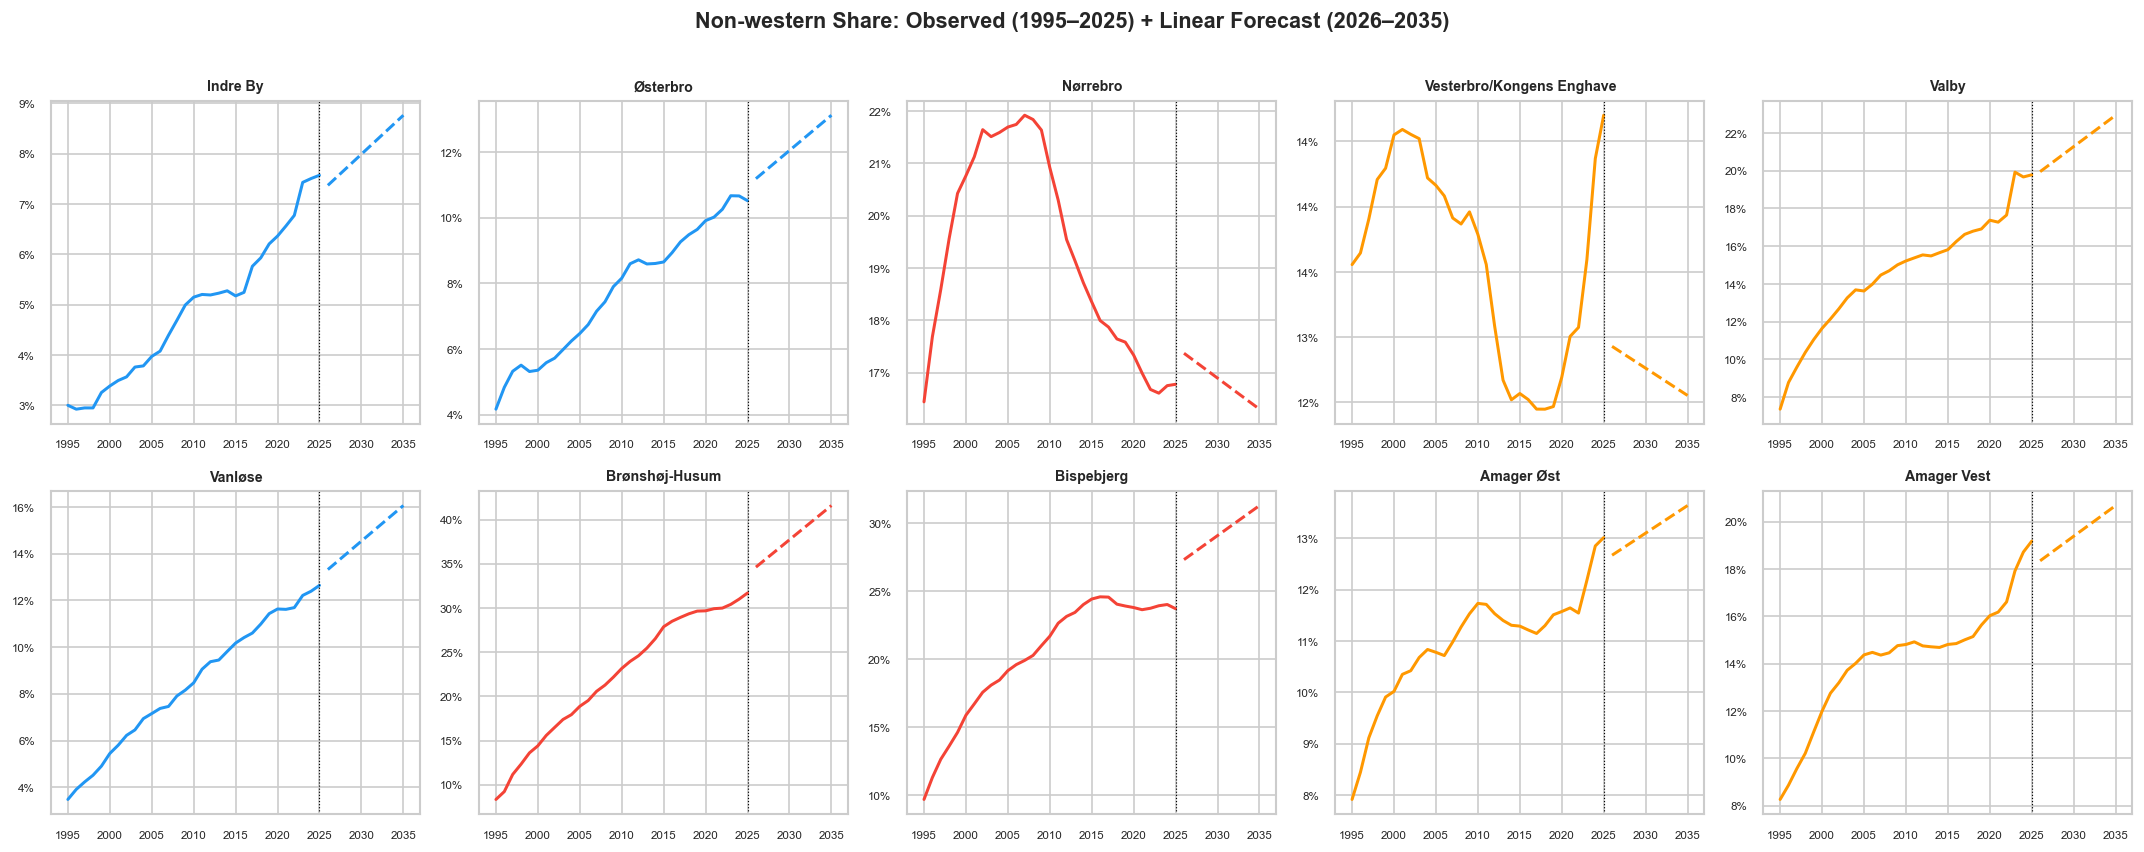

In [72]:
# Plot forecasts for all main districts
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes_flat = axes.flatten()

for i, (district, r) in enumerate(results.items()):
    ax = axes_flat[i]
    cname = cluster_df.loc[district, 'cluster_named'] if district in cluster_df.index else 'Unknown'
    color = palette.get(cname, 'grey')

    ax.plot(r['hist_years'], r['hist_vals'], color=color, linewidth=1.8, label='Observed')
    ax.plot(r['forecast_years'], r['forecast_vals'],
            color=color, linewidth=1.8, linestyle='--', label='Forecast')
    ax.axvline(2025, color='black', linewidth=0.7, linestyle=':')
    ax.set_title(district, fontsize=8.5, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.tick_params(labelsize=7)

# Remove empty subplot if < 10 districts
for j in range(len(results), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Non-western Share: Observed (1995–2025) + Linear Forecast (2026–2035)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("images/fig_14_forecasts.png", bbox_inches='tight')
plt.show()

The final forecast chart ranks all districts by their projected 2035 non-western share and overlays the 2025 actual value as a dashed outline bar. This makes the **expected growth differential** between districts concrete: which neighbourhoods are on track to change the most, and does the cluster structure persist into the forecast horizon?

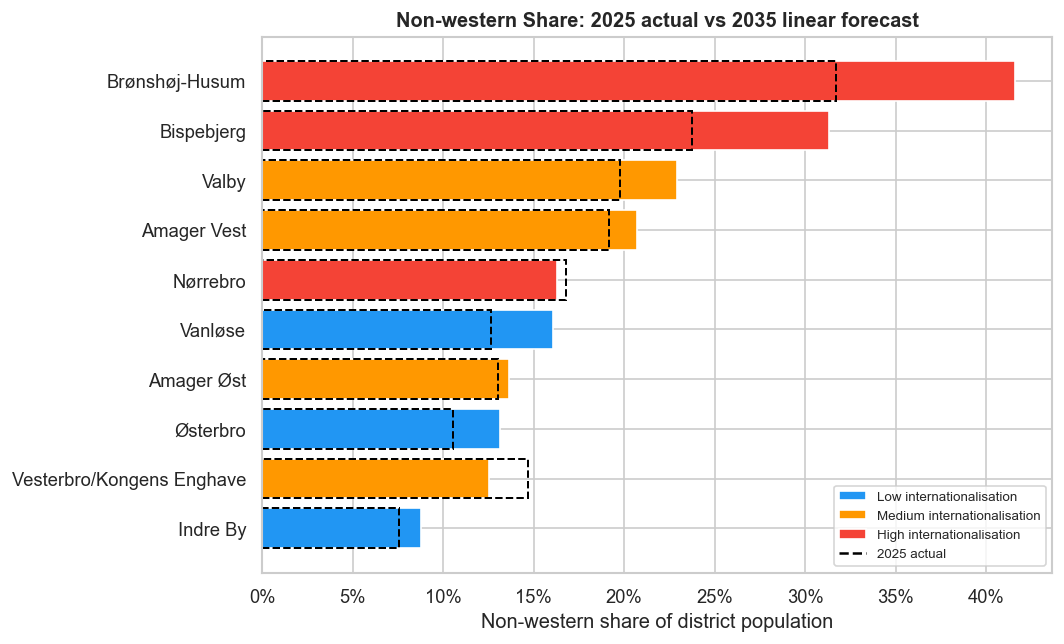

In [73]:
# Bar chart 2035 forecast by district, coloured by cluster
forecast_2035 = {d: r['forecast_vals'][-1] for d, r in results.items()}
forecast_df = pd.DataFrame({'district': list(forecast_2035.keys()),
                             'nw_share_2035': list(forecast_2035.values())})
forecast_df['actual_2025'] = forecast_df['district'].map(
    lambda d: nw_share.loc[d, '2025'] if d in nw_share.index else np.nan
)
forecast_df['cluster'] = forecast_df['district'].map(
    lambda d: cluster_df.loc[d, 'cluster_named'] if d in cluster_df.index else 'Unknown'
)
forecast_df = forecast_df.sort_values('nw_share_2035', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
bar_colors = [palette.get(c, 'grey') for c in forecast_df['cluster']]
bars = ax.barh(forecast_df['district'], forecast_df['nw_share_2035'],
               color=bar_colors, edgecolor='white', label='2035 forecast')
ax.barh(forecast_df['district'], forecast_df['actual_2025'],
        color='none', edgecolor='black', linewidth=1.2, linestyle='--',
        label='2025 actual (outline)')

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Non-western Share: 2025 actual vs 2035 linear forecast', fontweight='bold')
ax.set_xlabel('Non-western share of district population')

# Custom legend for clusters
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=palette[k], label=k) for k in palette]
legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='--', label='2025 actual'))
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig("images/fig_15_forecast_bar.png", bbox_inches='tight')
plt.show()

---
## 7. Visualizations

This section presents all interactive and geographic visualizations. We use **Plotly** for interactive charts (line charts, bar charts, heatmaps, scatter plots) and **Folium** for geographic maps a combination that lets the reader both track trends over time and see where in the city those changes are happening.

The visualizations are organized to follow the same narrative arc as the analysis: starting broad (city-wide population growth), then narrowing to districts, then exploring the composition of Copenhagen's international population, and finally mapping it geographically.

### 7.1 Copenhagen's total population growth, 1995–2025

Before looking at demographic composition, we establish the baseline: Copenhagen's overall population has grown substantially since 1995. A simple line chart is the right choice here the story is purely about a single trend over time, and a line chart communicates that more cleanly than any other format. It sets the stage for everything that follows: a growing city is a city that is also changing.

In [74]:
total_pop = (
    population_long[
        population_long["ancestry"] == "Ancestry total"
    ]
    .groupby("year", as_index=False)["population"]
    .sum()
)

fig = px.line(
    total_pop,
    x="year",
    y="population",
    markers=True,
    title="Copenhagen's population has grown steadily since 1995",
    labels={"year": "Year", "population": "Population"}
)

# Save interactive HTML
fig.write_html("images/fig_16_population_forecast_line_chart.html")

# Save static PNG
fig.write_image("images/fig_16_population_forecast_line_chart.png")

fig.show()

### 7.2 Population development by district

Not all districts grew equally. This interactive line chart lets the reader compare how each of the 10 main districts developed over the 30-year period. Color distinguishes districts, and Plotly's interactivity lets the reader isolate specific districts by clicking the legend useful for spotting outliers like Bispebjerg or Vesterbro, which grew far faster than others. This is important because the project focuses on whether demographic change was evenly distributed or concentrated in specific neighbourhoods.

In [75]:
main_districts = [
    "Indre By", "Østerbro", "Nørrebro", "Vesterbro/Kongens Enghave",
    "Valby", "Vanløse", "Brønshøj-Husum", "Bispebjerg",
    "Amager Øst", "Amager Vest"
]

district_pop = population_long[
    (population_long["district"].isin(main_districts)) &
    (population_long["ancestry"] == "Ancestry total")
]

fig = px.line(
    district_pop,
    x="year",
    y="population",
    color="district",
    title="Population development across Copenhagen districts",
    labels={"year": "Year", "population": "Population", "district": "District"}
)

# Save interactive HTML
fig.write_html("images/fig_17_population_development_line_chart.html")

# Save static PNG
fig.write_image("images/fig_17_population_development_line_chart.png")

fig.show()

### 7.3 International share of each district, 1995–2025

This is the central visualization of the project. Rather than showing raw population counts, the figure displays the share of residents with immigrant or descendant backgrounds. Using shares instead of absolute counts accounts for overall population growth and makes districts directly comparable across time.

A line chart is appropriate because the main pattern is temporal. The visualization highlights how districts followed different demographic trajectories between 1995 and 2025, with some districts experiencing substantially faster internationalisation than others.

The figure is intended to let readers compare neighbourhood-level change directly, without relying on predefined political categories or classifications. Instead, the patterns emerge from the demographic data itself.

In [76]:
international_groups = [
    "Immigrants of western origin",
    "Descendats of western origin",
    "Immigrants of non-western origin",
    "Descendants of non-western origin"
]

district_ancestry = population_long[
    population_long["district"].isin(main_districts)
]

international = (
    district_ancestry[district_ancestry["ancestry"].isin(international_groups)]
    .groupby(["district", "year"], as_index=False)["population"]
    .sum()
    .rename(columns={"population": "international_population"})
)

total = (
    district_ancestry[district_ancestry["ancestry"] == "Ancestry total"]
    [["district", "year", "population"]]
    .rename(columns={"population": "total_population"})
)

international_share = international.merge(total, on=["district", "year"])
international_share["international_share"] = (
    international_share["international_population"] /
    international_share["total_population"] * 100
)

fig = px.line(
    international_share,
    x="year",
    y="international_share",
    color="district",
    title="Share of residents with immigrant or descendant background by district",
    labels={
        "year": "Year",
        "international_share": "Share of population (%)",
        "district": "District"
    }
)

# Save interactive HTML
fig.write_html("images/fig_18_international_share_line_chart.html")

# Save static PNG
fig.write_image("images/fig_18_international_share_line_chart.png")

fig.show()

### 7.4 Which countries of origin grew the most?

Turning from districts to countries, this bar chart shows which origin communities expanded the most between 1995 and 2025 in absolute terms. A horizontal bar chart is the right choice here because we are ranking a set of named categories country names are long, and horizontal layout avoids label rotation. The chart supports the broader story by naming the communities behind the demographic shift.

In [77]:
origin_df = df_country.copy()
origin_total = (
    origin_df
    .groupby(["country", "year"], as_index=False)["population"]
    .sum()
)

origin_1995 = origin_total[origin_total["year"] == 1995][["country", "population"]]
origin_2025 = origin_total[origin_total["year"] == 2025][["country", "population"]]

growth = origin_2025.merge(origin_1995, on="country", suffixes=("_2025", "_1995"))
growth["absolute_growth"] = growth["population_2025"] - growth["population_1995"]

top_growth = growth.sort_values("absolute_growth", ascending=False).head(15)

fig = px.bar(
    top_growth,
    x="absolute_growth",
    y="country",
    orientation="h",
    title="Countries of origin with the largest population growth in Copenhagen (1995–2025)",
    labels={"absolute_growth": "Population growth 1995–2025", "country": "Country of origin"}
)

fig.update_layout(yaxis={"categoryorder": "total ascending"})

# Save interactive HTML
fig.write_html("images/fig_19_population_growth_bar_chart.html")

# Save static PNG
fig.write_image("images/fig_19_population_growth_bar_chart.png")
fig.show()

### 7.5 District × Year heatmap of international share

The heatmap compresses the entire 30-year time series for all 10 districts into a single readable view. Color intensity encodes the share of international residents, making it immediately obvious which districts experienced the strongest changes and *when* those changes accelerated. Unlike the line chart in section 5.3, the heatmap excels at showing the full temporal pattern simultaneously the reader can spot plateau effects, acceleration points (like the post-2015 levelling), and structural differences between districts at a glance. It directly supports the project's argument about uneven demographic development across the city.

In [86]:
# Prepare data using all districts (not just the 10 main ones for completeness)
international_groups_hm = [
    "Immigrants of western origin",
    "Descendats of western origin",
    "Immigrants of non-western origin",
    "Descendants of non-western origin"
]

district_data = population_long[
    population_long["district"].isin(main_districts)
]

intl_hm = (
    district_data[district_data["ancestry"].isin(international_groups_hm)]
    .groupby(["district", "year"], as_index=False)["population"]
    .sum()
)

total_hm = (
    district_data[district_data["ancestry"] == "Ancestry total"]
    [["district", "year", "population"]]
    .rename(columns={"population": "total_population"})
)

heatmap_df = intl_hm.merge(total_hm, on=["district", "year"])
heatmap_df["share"] = heatmap_df["population"] / heatmap_df["total_population"] * 100

pivot_df = heatmap_df.pivot(index="district", columns="year", values="share")

fig = px.imshow(
    pivot_df,
    aspect="auto",
    color_continuous_scale="Reds",
    title="Immigrant and descendant share by district (%)"
)
fig.update_layout(xaxis_title="Year", yaxis_title="District")

# Save interactive HTML
fig.write_html("images/fig_20_international_share_heatmap.html")

# Save static PNG
fig.write_image("images/fig_20_international_share_heatmap.png")
fig.show()

### 7.6 Geographic hotspot map - international share in 2025

The folium heatmap places the data back onto the city's actual geography. While line charts and heatmaps show *which* districts changed, only a map shows *where* in Copenhagen those districts are and whether the high-concentration areas are geographically clustered. The heat intensity corresponds to each district's international share in 2025. Markers show popup details (share, absolute counts) on click. This is the visualization that directly supports the spatial inequality argument: north-west Copenhagen shows persistently higher concentrations than the inner city or Amager.

In [79]:
international_groups_map = [
    "Immigrants of western origin",
    "Descendats of western origin",
    "Immigrants of non-western origin",
    "Descendants of non-western origin"
]

international_2025 = (
    population_long[
        (population_long["year"] == 2025) &
        (population_long["ancestry"].isin(international_groups_map))
    ]
    .groupby("district", as_index=False)["population"]
    .sum()
    .rename(columns={"population": "international_population"})
)

total_2025 = (
    population_long[
        (population_long["year"] == 2025) &
        (population_long["ancestry"] == "Ancestry total")
    ][["district", "population"]]
    .rename(columns={"population": "total_population"})
)

international_map_df = international_2025.merge(total_2025, on="district")
international_map_df["international_share"] = (
    international_map_df["international_population"] /
    international_map_df["total_population"] * 100
)
international_map_df = international_map_df.merge(district_coords, on="district")

m1 = folium.Map(location=[55.6761, 12.5683], zoom_start=11, tiles="OpenStreetMap")

heat_data_1 = international_map_df[["lat", "lon", "international_share"]].values.tolist()

HeatMap(heat_data_1, radius=45, blur=35, min_opacity=0.45, max_zoom=13).add_to(m1)

for _, row in international_map_df.iterrows():
    folium.Marker(
        location=[row["lat"], row["lon"]],
        tooltip=row["district"],
        popup=folium.Popup(
            f"<b>{row['district']}</b><br>"
            f"International share: {row['international_share']:.1f}%<br>"
            f"International population: {row['international_population']:,.0f}<br>"
            f"Total population: {row['total_population']:,.0f}",
            max_width=250
        )
    ).add_to(m1)

m1.save("maps/copenhagen_international_share_heatmap_2025.html")

m1


### 7.7 Geographic map - population change 1995 → 2025

This map shifts focus from composition to size: which districts physically grew the most? Circle markers are used (rather than heatmap intensity) because the key variable absolute population change is a quantity best encoded by size. Comparing this map to the hotspot map in 5.6 reveals a nuanced story: the districts with the highest international shares are not always the ones that grew the most in absolute population terms, suggesting that internationalisation and overall growth are related but distinct phenomena.

In [ ]:
pop_1995_map = population_long[
    (population_long["year"] == 1995) &
    (population_long["ancestry"] == "Ancestry total") &
    (population_long["district"].isin(district_coords["district"]))
][["district", "population"]].rename(columns={"population": "population_1995"})

pop_2025_map = population_long[
    (population_long["year"] == 2025) &
    (population_long["ancestry"] == "Ancestry total") &
    (population_long["district"].isin(district_coords["district"]))
][["district", "population"]].rename(columns={"population": "population_2025"})

change_map_df = pop_1995_map.merge(pop_2025_map, on="district")
change_map_df["absolute_change"] = change_map_df["population_2025"] - change_map_df["population_1995"]
change_map_df["percent_change"] = change_map_df["absolute_change"] / change_map_df["population_1995"] * 100
change_map_df = change_map_df.merge(district_coords, on="district")

m2 = folium.Map(location=[55.6761, 12.5683], zoom_start=11, tiles="OpenStreetMap")

for _, row in change_map_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=max(row["absolute_change"] / 2500, 5),
        popup=folium.Popup(
            f"<b>{row['district']}</b><br>"
            f"Population 1995: {row['population_1995']:,.0f}<br>"
            f"Population 2025: {row['population_2025']:,.0f}<br>"
            f"Change: +{row['absolute_change']:,.0f}<br>"
            f"Percent change: +{row['percent_change']:.1f}%",
            max_width=250
        ),
        tooltip=row["district"],
        fill=True,
        fill_opacity=0.7
    ).add_to(m2)

m2.save("maps/copenhagen_population_change_1995_2025.html")

m2


### 7.8 Animated map - international share evolving 1995–2025

The animated density map is the most expressive visualization in the project. By replaying 31 years frame by frame, it shows *when* the geographic concentration patterns emerged not just where they ended up. This is important for the project's argument: the spatial inequality we observe in 2025 was not always there; it developed gradually, with visible acceleration after 2000 in the north-western districts. The Plotly `density_mapbox` format was chosen over a static map precisely because the temporal dimension is as important as the spatial one.

In [81]:

international_groups_anim = [
    "Immigrants of western origin",
    "Descendats of western origin",
    "Immigrants of non-western origin",
    "Descendants of non-western origin"
]

years_anim = list(range(1995, 2026))
animated_rows = []

for year in years_anim:
    intl_y = (
        population_long[
            (population_long["year"] == year) &
            (population_long["ancestry"].isin(international_groups_anim))
        ]
        .groupby("district", as_index=False)["population"]
        .sum()
        .rename(columns={"population": "international_population"})
    )
    total_y = (
        population_long[
            (population_long["year"] == year) &
            (population_long["ancestry"] == "Ancestry total")
        ][["district", "population"]]
        .rename(columns={"population": "total_population"})
    )
    yearly = intl_y.merge(total_y, on="district")
    yearly["international_share"] = yearly["international_population"] / yearly["total_population"] * 100
    yearly = yearly.merge(district_coords, on="district")
    yearly["year"] = year
    animated_rows.append(yearly[["year", "lat", "lon", "international_share"]])

animated_df = pd.concat(animated_rows, ignore_index=True)

fig = px.density_mapbox(
    animated_df,
    lat="lat",
    lon="lon",
    z="international_share",
    animation_frame="year",
    radius=45,
    center={"lat": 55.6761, "lon": 12.5683},
    zoom=10.5,
    mapbox_style="open-street-map",
    title="Animated hotspot map - international population share, 1995–2025"
)


# Save interactive HTML
fig.write_html("images/fig_21_animated_international_share_map.html")

# Save static PNG
fig.write_image("images/fig_21_animated_international_share_map.png")
fig.show()

### 7.9 District cluster analysis - interactive PCA scatter

This interactive scatter plot visualises the KMeans clustering from Section 4 in a different way from the static matplotlib version. Here we cluster on three features, international share, income, and population growth, and project onto two principal components for display. Using Plotly allows the reader to hover over each district to see its exact values, making the cluster membership interpretable rather than just abstract. The bubble size encodes population growth, adding a fourth dimension without clutter.

In [82]:
# Prepare income dataframe for clustering
district_df = df.copy()

# Define Copenhagen's 10 main districts
main_districts = [
    "Indre By",
    "Østerbro",
    "Nørrebro",
    "Vesterbro/Kongens Enghave",
    "Valby",
    "Vanløse",
    "Brønshøj-Husum",
    "Bispebjerg",
    "Amager Øst",
    "Amager Vest"
]

In [83]:
# Income for 2024 (from district_df)
income_cols_list = [c for c in district_df.columns if c.startswith('avg_income_dkk_')]

income_long_df = district_df.melt(
    id_vars=['age_group', 'sex', 'ancestry', 'district'],
    value_vars=income_cols_list,
    var_name='year',
    value_name='avg_income_dkk'
)
income_long_df['year'] = income_long_df['year'].str.replace('avg_income_dkk_', '', regex=False).astype(int)

income_2024 = (
    income_long_df[
        (income_long_df['year'] == 2024) &
        (income_long_df['age_group'] == 'Years in total') &
        (income_long_df['sex'] == 'Sex total') &
        (income_long_df['ancestry'] == 'Ancestry total') &
        (income_long_df['district'].isin(main_districts))
    ][["district", "avg_income_dkk"]]
    .drop_duplicates(subset='district')
)

international_2024 = (
    population_long[
        (population_long['year'] == 2024) &
        (population_long['ancestry'].str.contains('Immigrant|Descendant|Descendat', case=False, na=False))
    ]
    .groupby('district', as_index=False)['population']
    .sum()
    .rename(columns={'population': 'international_population'})
)

total_2024_c = (
    population_long[
        (population_long['year'] == 2024) &
        (population_long['ancestry'] == 'Ancestry total')
    ][['district', 'population']]
    .rename(columns={'population': 'total_population'})
)

share_2024 = international_2024.merge(total_2024_c, on='district')
share_2024['international_share'] = share_2024['international_population'] / share_2024['total_population'] * 100

# Population growth
pop_1995_c = population_long[
    (population_long['year'] == 1995) & (population_long['ancestry'] == 'Ancestry total')
][['district', 'population']].rename(columns={'population': 'population_1995'})

pop_2024_c = population_long[
    (population_long['year'] == 2024) & (population_long['ancestry'] == 'Ancestry total')
][['district', 'population']].rename(columns={'population': 'population_2024'})

growth_df = pop_1995_c.merge(pop_2024_c, on='district')
growth_df['population_growth_percent'] = (growth_df['population_2024'] - growth_df['population_1995']) / growth_df['population_1995'] * 100

# Merge all features
cluster_input = (
    income_2024
    .merge(share_2024[['district', 'international_share']], on='district')
    .merge(growth_df[['district', 'population_growth_percent']], on='district')
    .dropna()
)
cluster_input = cluster_input[cluster_input['district'].isin(main_districts)]

features_c = cluster_input[['international_share', 'avg_income_dkk', 'population_growth_percent']]
scaler_c = StandardScaler()
scaled_c = scaler_c.fit_transform(features_c)

kmeans_c = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_input['cluster'] = kmeans_c.fit_predict(scaled_c)

pca_c = PCA(n_components=2)
pca_vals = pca_c.fit_transform(scaled_c)
cluster_input['pca1'] = pca_vals[:, 0]
cluster_input['pca2'] = pca_vals[:, 1]

fig = px.scatter(
    cluster_input,
    x='pca1', y='pca2',
    color=cluster_input['cluster'].astype(str),
    size='population_growth_percent',
    hover_name='district',
    hover_data={
        'international_share': ':.1f',
        'avg_income_dkk': ':,.0f',
        'population_growth_percent': ':.1f',
        'cluster': True
    },
    title='Cluster analysis of Copenhagen districts (international share, income, population growth)',
    labels={
        'pca1': 'Principal component 1',
        'pca2': 'Principal component 2',
        'color': 'Cluster'
    }
)

# Save interactive HTML
fig.write_html("images/fig_22_cluster_analysis_scatter_plot.html")

# Save static PNG
fig.write_image("images/fig_22_cluster_analysis_scatter_plot.png")
fig.show()

---
## 8. Key Findings Summary

Here we print a clean summary of the main numbers for the website text.

The code below assembles the most important numbers from each section into a single printed summary city-wide share change, the most and least international districts, cluster membership, top origin countries, the immigrant-vs-descendant split, and the income gap by ancestry group. These figures feed directly into the narrative text on the project website.

In [84]:
print('='*65)
print('KEY FINDINGS')
print('='*65)

share_1995 = city_share['1995']
share_2025 = city_share['2025']
print(f'\n1. City-wide international share rose from {share_1995:.1f}% (1995) '
      f'to {share_2025:.1f}% (2025) - a +{share_2025-share_1995:.1f} pp increase.')

highest_dist = share['2025'].idxmax()
lowest_dist  = share['2025'].idxmin()
print(f'\n2. Most international district in 2025: {highest_dist} '
      f'({share.loc[highest_dist, "2025"]:.1f}%)')
print(f'   Least international: {lowest_dist} '
      f'({share.loc[lowest_dist, "2025"]:.1f}%)')

print(f'\n3. Cluster summary:')
for cname in ['High internationalisation', 'Medium internationalisation', 'Low internationalisation']:
    members = cluster_df[cluster_df['cluster_named'] == cname].index.tolist()
    print(f'   {cname}: {members}')

print(f'\n4. Top 3 origin countries in 2024:')
top3 = df_foreign[df_foreign['year'] == 2024].groupby('country')['population'].sum().sort_values(ascending=False).head(3)
for country, pop in top3.items():
    print(f'   {country}: {pop:,}')

print(f'\n5. Generational shift (2024):')
gen_2024 = gen_ts[gen_ts['year'] == 2024].set_index('ancestry')['population']
for anc in ['Immigrants', 'Descendant']:
    if anc in gen_2024.index:
        print(f'   {anc}: {gen_2024[anc]:,}')

print(f'\n6. Income gap (2024):')
inc_2024 = income_long[income_long['year'] == 2024].set_index('group')['avg_income']
for g in ['Danish origin', 'Non-western immigrants', 'Non-western descendants']:
    if g in inc_2024.index:
        print(f'   {g}: {inc_2024[g]/1000:.0f}k DKK/yr')

print('\n' + '='*65) 

KEY FINDINGS

1. City-wide international share rose from 13.0% (1995) to 28.2% (2025) - a +15.2 pp increase.

2. Most international district in 2025: Brønshøj-Husum (38.4%)
   Least international: Vanløse (20.2%)

3. Cluster summary:
   High internationalisation: ['Bispebjerg', 'Brønshøj-Husum', 'Nørrebro']
   Medium internationalisation: ['Amager Vest', 'Amager Øst', 'Valby', 'Vesterbro/Kongens Enghave']
   Low internationalisation: ['Indre By', 'Vanløse', 'Østerbro']

4. Top 3 origin countries in 2024:
   Turkey: 66,738
   Poland: 56,749
   Romania: 45,985

5. Generational shift (2024):
   Immigrants: 724,636
   Descendant: 218,381

6. Income gap (2024):
   Danish origin: 317k DKK/yr
   Non-western immigrants: 242k DKK/yr
   Non-western descendants: 203k DKK/yr



---
## 9. Discussion

This section reflects critically on the project what worked, what is still missing, and what could be improved with more time or data.

### 9.1 What went well

**Data coverage.** 
The district-level dataset spans 30 years (1995–2025) at annual resolution across Copenhagen’s 10 main boroughs. This temporal depth made it possible to examine long-term demographic development rather than isolated snapshots, which is essential for understanding gradual neighbourhood-level change over time.

**The clustering result is interpretable.**
The KMeans clustering approach (k=3) produced district groupings that were broadly interpretable in relation to known demographic patterns within Copenhagen. Districts such as Nørrebro and Brønshøj-Husum were grouped within the high-internationalisation cluster, while several inner-city and Amager districts appeared in lower-share groups. The clustering therefore helped simplify many individual district trajectories into a smaller set of readable neighbourhood types.

**Visualization variety.**
The project combines static Matplotlib/Seaborn figures for analytical clarity, interactive Plotly visualizations for detailed exploration, and Folium maps for geographic context. This variety allows readers to engage with the data at multiple levels, from broad trends to district-specific inspection. The animated map was especially effective for showing how demographic change developed spatially over time.

**Avoiding political framing.**
The analysis focuses on measurable demographic indicators such as population shares and long-term trends rather than predefined administrative or political classifications. This keeps the project centered on observable spatial patterns and makes the visualizations easier to interpret objectively.

### 9.2 What is still missing and why

**Income data is unreliable at district level.** The income variable available in the dataset showed very limited variation between districts, suggesting that it may reflect broader city-level averages rather than fully district-specific income measurements. As a result, the project uses the income analysis primarily as contextual background rather than as a central explanatory variable.
A more detailed district-level income dataset, such as one retrieved directly from Statistics Denmark through a separate API query, would likely strengthen the analysis of socioeconomic inequality and its relationship to demographic change..

**Sub-district granularity.** The 10-borough unit is quite coarse. Nørrebro, for example, contains both very high-concentration streets and rapidly gentrifying blocks. Parish-level or street-level data would let us show within-district variation, but that data is not publicly available in the same format.

**No causal analysis.** The project documents *that* districts differ and *that* certain trends occurred, but cannot explain *why*. Housing policy, migration flows, and gentrification all interact. Linking the demographic data to housing price data or social housing registers would be a natural next step.

**Nationality data is city-level only.** The country-of-origin dataset does not break down by district, so we cannot say whether, for example, Pakistani-origin residents are concentrated in specific boroughs or spread evenly. This limits the depth of the composition story.

### 9.3 What could be improved

**The forecast model is intentionally simple.**
The linear OLS trend model works well for illustrating long-term directionality and produced relatively high R² values across districts. However, demographic trends rarely continue linearly indefinitely. More advanced approaches such as logistic growth models, ARIMA forecasting, or models with uncertainty intervals would likely produce more realistic long-run projections. The current forecasts should therefore be interpreted as exploratory “what-if” scenarios rather than precise predictions.

**The animated map could be smoother.**
The Plotly density_mapbox animation progresses through discrete yearly frames, which can make temporal change appear visually abrupt. A WebGL-based or interpolated animation approach could create smoother transitions and improve the visual continuity of the demographic development over time.

**Choropleth mapping would improve spatial accuracy.**
The Folium HeatMap visualizes district-level values using smoothed point intensity layers. While effective for showing overall spatial concentration, this approach does not represent the actual administrative boundaries of Copenhagen’s boroughs. Using GeoJSON district polygons would allow the creation of choropleth maps, where colour is applied directly to each borough area. This would provide a more geographically accurate and interpretable district-level visualization.

**Accessibility could be improved.**
The interactive Plotly charts and Folium maps are not fully accessible to screen-reader users. Static fallback figures, descriptive captions, or alternative text summaries would improve accessibility and make the project more suitable for public-facing publication.

---
## 10. Notes on Methodology

**Clustering**: 
We used KMeans (k=3) on non-western share at 7 time snapshots (1995–2025). Features were standardised before fitting. k=3 was selected via the elbow method. We used PCA for 2D visualisation only clustering was done in the original 7-dimensional feature space.

**Forecasting**: 
Linear regression on the annual non-western share time-series per district (31 data points, 1995–2025). R² values are generally high (>0.85 for most districts), confirming strong linear trends over the observation period. However, linear extrapolation assumes the trend continues unchanged, real demographic dynamics may plateau, accelerate, or reverse due to policy, housing supply, or economic shifts.

**Data limitation - nationalities**: 
The country-of-origin dataset is only available at the Copenhagen city level, not per district. We therefore analyse nationality composition and the immigrant-vs-descendant split only for the city as a whole.

**Income data**: 
Available from 2008 onward. The income gap between ancestry groups is an aggregate average it reflects both compositional effects (education, age structure, years in Denmark) and structural factors (labour market discrimination, occupational segregation).